# ejercicio

1. Preparación del entorno

In [39]:
# Librerías básicas
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# Configuraciones estéticas
sns.set(style="whitegrid")


2. Carga de datos y EDA inicial

In [3]:
# 1. Carga
df = pd.read_csv(r"C:\americo\ia_dema\12_Machine Learning\03_Clusterización\train.csv")

# 2. Dimensión y primeras filas
print("---------shape-------")
print(df.shape)
display(df.head())

# 3. Tipos y valores faltantes
print("---------info-------")
display(df.info())
print("---------insa-------")
display(df.isna().sum().sort_values(ascending=False).head(20))

# 4. Estadísticos básicos para numéricos
print("---------describe-------")
display(df.describe())


---------shape-------
(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---------info-------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   

None

---------insa-------


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Id                 0
dtype: int64

---------describe-------


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


3. Análisis de valores faltantes

In [4]:
# % de faltantes por columna
faltantes = df.isna().mean().sort_values(ascending=False) * 100
display(faltantes[faltantes > 0].head(20))


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageYrBlt      5.547945
GarageCond       5.547945
GarageType       5.547945
GarageFinish     5.547945
GarageQual       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

3. Manejo de valores faltantes
A partir del análisis vemos distintos niveles de ausencia. La estrategia general es:

Eliminar columnas con casi todo faltante.

Rellenar según el significado de la ausencia (p. ej. “no existe elemento”).

Imputar numéricos usando medianas o valores por grupo.

Imputar categóricos con “None” o moda.

3.1 Drop de columnas con > 80 % faltantes

In [5]:
to_drop = ['PoolQC','MiscFeature','Alley','Fence']
df.drop(columns=to_drop, inplace=True)


3.2 Rellenar “ausencia real” de elementos
MasVnrType / MasVnrArea: si falta, no hay revestimiento cerámico.

FireplaceQu: si falta, no hay chimenea.

In [11]:
df['MasVnrType']   = df['MasVnrType'].fillna('None')
df['MasVnrArea']   = df['MasVnrArea'].fillna(0)
df['FireplaceQu']  = df['FireplaceQu'].fillna('None')


3.3 Imputación de sótanos y garajes
Los nulos en Bsmt* y Garage* suelen significar “sin sótano/garaje”.

In [12]:
# 3.3 Imputación de sótanos
bsmt_cols = [
    'BsmtQual','BsmtCond','BsmtExposure',
    'BsmtFinType1','BsmtFinType2'
]

# Rellenar variables categóricas de sótano
df[bsmt_cols] = df[bsmt_cols].fillna('None')

# Rellenar variables numéricas de sótano
num_bsmt = [
    'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
    'TotalBsmtSF','BsmtFullBath','BsmtHalfBath'
]
df[num_bsmt] = df[num_bsmt].fillna(0)


# 3.4 Imputación de garaje
garage_cat = ['GarageType','GarageFinish','GarageQual','GarageCond']
df[garage_cat] = df[garage_cat].fillna('None')

df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

garage_num = ['GarageCars','GarageArea']
df[garage_num] = df[garage_num].fillna(0)


3.4 LotFrontage por vecindario
LotFrontage varía por barrio, imputamos con la mediana de cada Neighborhood:

In [8]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                        .transform(lambda x: x.fillna(x.median()))


3.5 Categóricos residuales y eléctricos
MasVnrType ya imputado.

Electrical: casi completo, rellenar con la moda.

In [14]:
mode_elec = df['Electrical'].mode()[0]
df['Electrical'] = df['Electrical'].fillna(mode_elec)


3.6 Verificación final


In [15]:
display(df.isna().sum()[df.isna().sum()>0])

Series([], dtype: int64)

### Tras cargar/limpiar df, define las columnas numéricas

In [21]:

num_cols = df.select_dtypes(include=[np.number]).columns

4. Visualización y correlaciones

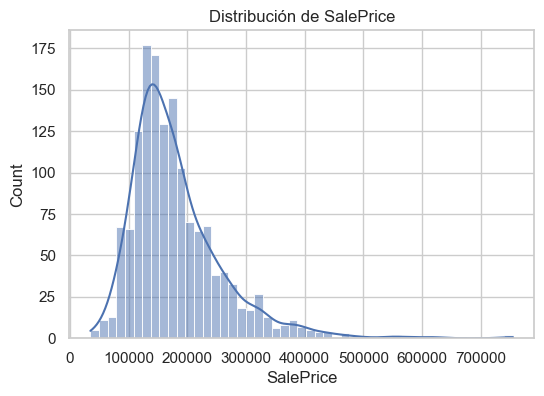

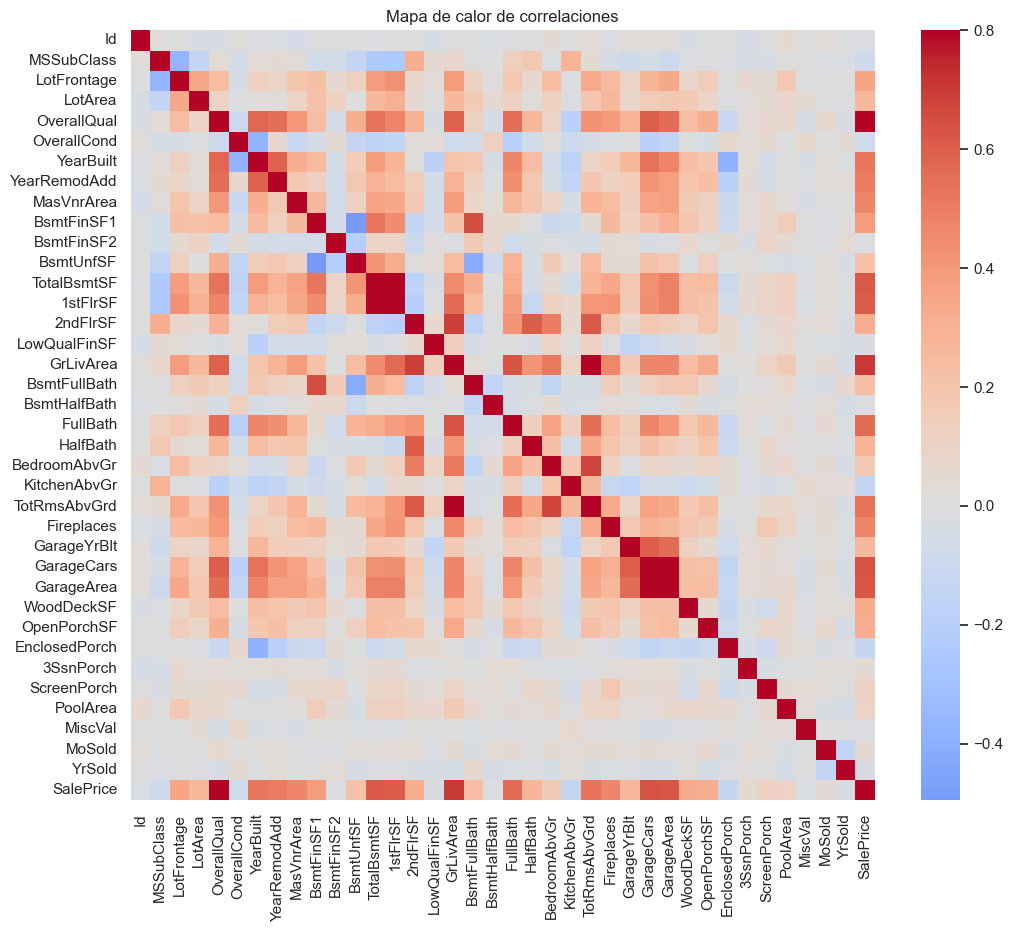

In [23]:
# Distribución de precio de venta
plt.figure(figsize=(6,4))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribución de SalePrice")
plt.show()

# Matriz de correlaciones numéricas
corrmat = df[num_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corrmat, cmap="coolwarm", center=0, vmax=0.8)
plt.title("Mapa de calor de correlaciones")
plt.show()



5. Preprocesamiento para clusterización
   
        Seleccionar features: evitar ID y target.

        One-hot encoding de categóricas.

        Estandarizar todas las columnas.


### 1. Excluir ID y SalePrice

In [ ]:

X = df.drop(["Id", "SalePrice"], axis=1)


### 2. One-hot

In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:
### 3. Estandarización

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

6. Reducción dimensional para visualización (PCA)

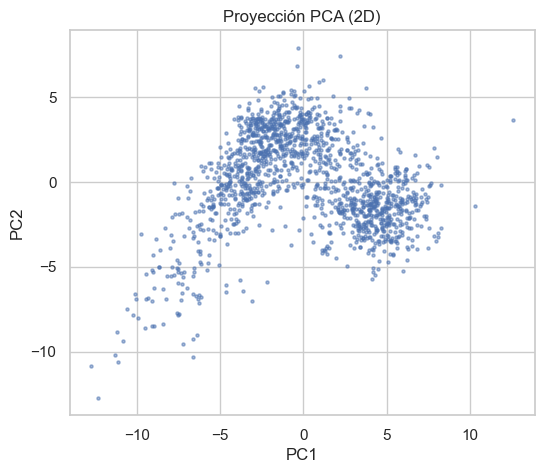

In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Proyección PCA (2D)")
plt.show()


7. Determinar número óptimo de clusters

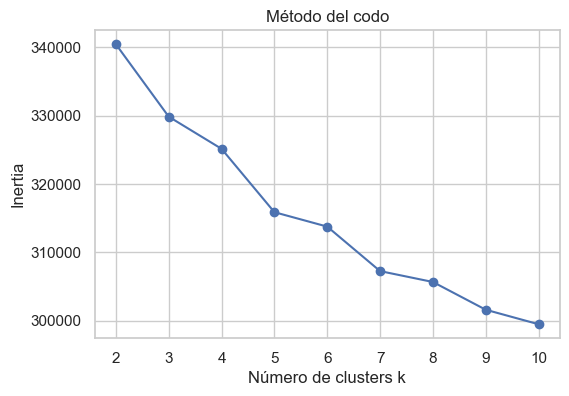

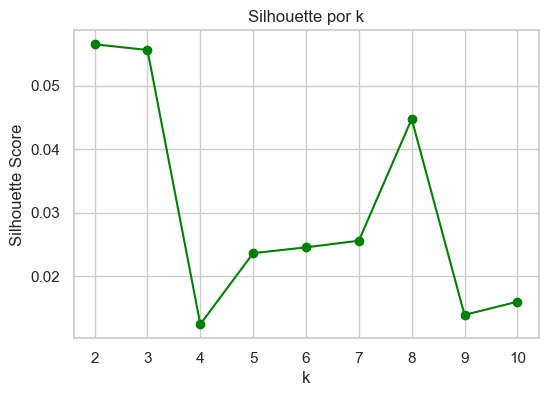

In [34]:
# Método del codo
inertia = []
K = range(2,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Número de clusters k")
plt.ylabel("Inertia")
plt.title("Método del codo")
plt.show()

# Silhouette
sil = []
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil.append(silhouette_score(X_scaled, labels))
    
plt.figure(figsize=(6,4))
plt.plot(K, sil, marker='o', color='green')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette por k")
plt.show()


8. Entrenar K-Means
   
       Suponiendo que k=4 es razonable

In [35]:

k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Añadir etiqueta al df original
df["Cluster"] = cluster_labels


9. Visualizar clusters en PCA

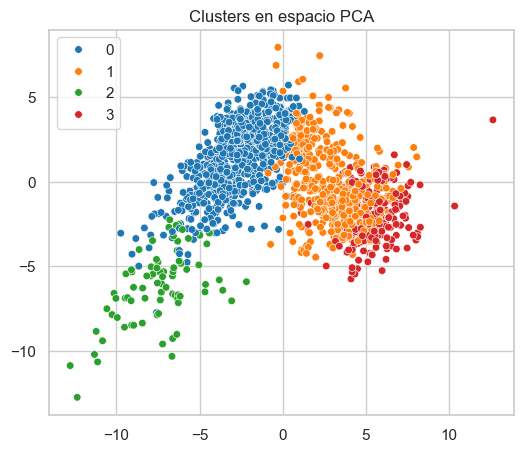

In [36]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x=X_pca[:,0], y=X_pca[:,1],
    hue=cluster_labels,
    palette="tab10",
    legend="full", s=30
)
plt.title("Clusters en espacio PCA")
plt.show()


10. Interpretación de clusters

In [37]:
# Centroides en escala original
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=X.columns)

# Ver primeras 10 variables más altas/bajas por cluster
for i in range(k_opt):
    print(f"\nCluster {i}:")
    print(centroids_df.iloc[i]
          .sort_values(ascending=False)
          .head(10))



Cluster 0:
LotArea         9578.250712
YrSold          2007.847578
YearRemodAdd    1972.490028
GarageYrBlt     1961.115385
YearBuilt       1950.797721
GrLivArea       1307.038462
1stFlrSF        1058.817664
TotalBsmtSF      908.239316
BsmtUnfSF        464.313390
GarageArea       414.075499
Name: 0, dtype: float64

Cluster 1:
LotArea         12139.354251
YrSold           2007.882591
YearRemodAdd     1996.097166
GarageYrBlt      1993.097166
YearBuilt        1992.331984
GrLivArea        1760.285425
1stFlrSF         1215.453441
TotalBsmtSF      1139.639676
BsmtUnfSF         594.340081
GarageArea        550.702429
Name: 1, dtype: float64

Cluster 2:
LotArea         7487.939024
YrSold          2007.865854
YearRemodAdd    1974.865854
YearBuilt       1942.207317
GrLivArea       1186.792683
1stFlrSF         917.682927
TotalBsmtSF      770.085366
BsmtUnfSF        512.768293
BsmtFinSF1       237.451220
2ndFlrSF         234.585366
Name: 2, dtype: float64

Cluster 3:
LotArea         11097.719780
Y

### 11. Refinar imputación avanzada (KNN y MICE)

### Identificar características numéricas

In [40]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
num_features.remove('SalePrice')  # excluir target
num_features.remove('Cluster')    # si ya la añadiste


### 11.1 KNN Imputer

In [41]:
knn_imp = KNNImputer(n_neighbors=5)
df[num_features] = knn_imp.fit_transform(df[num_features])

### 11.2 MICE / Iterative Imputer

In [43]:
mice_imp = IterativeImputer(random_state=42)
df[num_features] = mice_imp.fit_transform(df[num_features])

### 12. Crear variables derivadas e incluir Cluster como feature

(si no lo tienes aun)
df['Cluster'] = cluster_labels  

### Edad de la vivienda y remodelación

In [44]:
df['HouseAge']  = df['YrSold'] - df['YearBuilt']
df['RemodAge']  = df['YrSold'] - df['YearRemodAdd']

### Espacios totales en pies cuadrados

In [45]:

df['TotalSF']   = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']


### Área total de porches

In [46]:
df['PorchArea'] = (df['WoodDeckSF'] + df['OpenPorchSF'] +
                   df['EnclosedPorch'] + df['3SsnPorch'] +
                   df['ScreenPorch'])

### 13. Preparar datos para supervisado

In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, classification_report


In [48]:

# Features y targets
X = df.drop(columns=['SalePrice'])
y_reg = df['SalePrice']


In [49]:

# Clasificación: discretizar SalePrice en 3 grupos iguales
df['SaleCat'] = pd.qcut(df['SalePrice'], q=3,
                        labels=['Low','Medium','High'])
y_clf = df['SaleCat']


In [50]:

# Dividir en train/test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)


In [51]:

# Columnas numéricas y categóricas
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=['object','category']).columns.tolist()


In [52]:

# Preprocesador
num_pipe = Pipeline([('scaler', StandardScaler())])
cat_pipe = Pipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))])

preproc = ColumnTransformer([
    ('num', num_pipe, num_feats),
    ('cat', cat_pipe, cat_feats)
])



### 13.1 Regresión con RandomForest + GridSearchCV

In [53]:
reg_pipe = Pipeline([
    ('pre', preproc),
    ('rf', RandomForestRegressor(random_state=42))
])

param_grid_r = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20]
}

gs_reg = GridSearchCV(reg_pipe, param_grid_r,
                      cv=5,
                      scoring='neg_root_mean_squared_error',
                      n_jobs=-1)
gs_reg.fit(X_train_r, y_train_r)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Id',
                                                                          'MSSubClass',
                                                                          'LotFrontage',
                                                                          'LotArea',
                                                                          'OverallQual',
                                                                          'OverallCond',
                                                                          'YearBuilt',
                                                                          'YearRemodAdd',
                                                                          'MasVnrArea',
                                                                          'BsmtFinSF1',
                                                                          'BsmtFinSF2',
                                                                          'BsmtUnfSF',
                                                                          'TotalBsmtSF',
                                                                          '1stFlrSF',
                                                                          '2ndFlrSF',
                                                                          'LowQualFinSF',
                                                                          'GrLivArea',
                                                                          'B...
                                                                          'MasVnrType',
                                                                          'ExterQual',
                                                                          'ExterCond',
                                                                          'Foundation',
                                                                          'BsmtQual',
                                                                          'BsmtCond',
                                                                          'BsmtExposure',
                                                                          'BsmtFinType1',
                                                                          'BsmtFinType2',
                                                                          'Heating',
                                                                          'HeatingQC',
                                                                          'CentralAir',
                                                                          'Electrical',
                                                                          'KitchenQual', ...])])),
                                       ('rf',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20],
                         'rf__n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

In [58]:
from sklearn.metrics import root_mean_squared_error

# …
y_pred_r = gs_reg.predict(X_test_r)
rmse = root_mean_squared_error(y_test_r, y_pred_r)
print(f"Mejor RMSE (test): {rmse:.2f}")


Mejor RMSE (test): 29930.96



### 13.2 Clasificación con RandomForest + GridSearchCV

In [56]:

clf_pipe = Pipeline([
    ('pre', preproc),
    ('rf', RandomForestClassifier(random_state=42))
])

param_grid_c = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [None, 10, 20]
}

gs_clf = GridSearchCV(clf_pipe, param_grid_c,
                      cv=5,
                      scoring='accuracy',
                      n_jobs=-1)
gs_clf.fit(X_train_c, y_train_c)

# Evaluar
y_pred_c = gs_clf.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))
print("Mejores parámetros:", gs_clf.best_params_)


              precision    recall  f1-score   support

        High       0.91      0.89      0.90        94
         Low       0.83      0.93      0.88       110
      Medium       0.78      0.68      0.73        88

    accuracy                           0.84       292
   macro avg       0.84      0.83      0.84       292
weighted avg       0.84      0.84      0.84       292

Mejores parámetros: {'rf__max_depth': 20, 'rf__n_estimators': 200}


### 14. Validación cruzada final

In [57]:
from sklearn.model_selection import cross_val_score

# CV en regresión
cv_rmse = -cross_val_score(
    gs_reg.best_estimator_, X, y_reg,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
print(f"CV RMSE promedio: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

# CV en clasificación
cv_acc = cross_val_score(
    gs_clf.best_estimator_, X, y_clf,
    cv=5, scoring='accuracy', n_jobs=-1
)
print(f"CV Accuracy promedio: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")


CV RMSE promedio: 29419.18 ± 4121.50
CV Accuracy promedio: 0.847 ± 0.018
